# Combining Multiple Losses

This notebook trains the digit classifier from the [MNIST Addition notebook](MNIST%20Addition.ipynb) using **two independent logical constraints at once**:

1. The **addition constraint**: pairs of images and their sum are the only supervision (no individual digit labels).
2. The **exactly-one constraint** from the [Semi-Supervised MNIST notebook](Semi-Supervised%20MNIST.ipynb): applied here to a separate pool of unlabeled single images, as an auxiliary regularizer on top of the addition signal.

Both constraints act on the *same* shared classifier, but they are built as two separate `LogicLoss` objects: different predicates, different variables, different data loaders, different batch sizes. This is exactly the setting `CombinedLoss` is for -- see [Combining Multiple Losses](https://pysignet.github.io/concepts/#combining-multiple-losses) in the docs for the distinction between this (loss-level combination) and conjoining expressions with `sp.And` (satisfaction-level combination).

By the end of this notebook, we will have seen:

1. How to combine two independently compiled `LogicLoss` objects with `CombinedLoss`
2. Why `CombinedLoss.trainable_parameters` deduplicates parameters when both constraints share the same underlying model
3. How sweeping the auxiliary constraint's weight reveals a real trade-off, rather than a free accuracy win

## Preliminaries

The usual imports. (`torchvision` is not a `pysignet` dependency and needs to be installed separately.)

In [1]:
%pip install torchvision -q -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

import pysignet as psn
from pysignet import CombinedLoss

## The data

We need two data sources that never overlap in what they supervise:

- **Addition pairs**: two images and their sum (reused from the MNIST Addition notebook).
- **Unlabeled singles**: plain MNIST images, with labels discarded, used only for the exactly-one constraint.

In [3]:
class MNISTAdditionDataset(Dataset):
    """Dataset of MNIST image pairs with their sums."""

    def __init__(self, mnist_dataset, n_pairs: int = 10000):
        self.mnist = mnist_dataset
        self.n_pairs = n_pairs
        self.indices = torch.randint(0, len(mnist_dataset), (n_pairs, 2))

    def __len__(self):
        return self.n_pairs

    def __getitem__(self, idx):
        idx1, idx2 = self.indices[idx]
        img1, label1 = self.mnist[idx1]
        img2, label2 = self.mnist[idx2]
        return {"img1": img1, "img2": img2, "sum": label1 + label2}

In [4]:
torch.manual_seed(42)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: x.view(-1))  # Flatten to 784
])

train_mnist = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_mnist = datasets.MNIST('./data', train=False, transform=transform)

# Addition pairs: the primary training signal.
train_addition = MNISTAdditionDataset(train_mnist, n_pairs=10000)
test_addition = MNISTAdditionDataset(test_mnist, n_pairs=2000)
train_addition_loader = DataLoader(train_addition, batch_size=64, shuffle=True)
test_addition_loader = DataLoader(test_addition, batch_size=256, shuffle=False)

# Unlabeled singles: a separate pool of images for the auxiliary constraint.
# Labels are discarded -- the entropy constraint never sees them.
unlabeled_indices = torch.randperm(len(train_mnist))[:5000]
unlabeled_dataset = Subset(train_mnist, unlabeled_indices)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=128, shuffle=True)

# Held out for measuring digit accuracy (evaluation only, never used for training).
eval_test_loader = DataLoader(test_mnist, batch_size=256, shuffle=False)

print(f"Addition training pairs: {len(train_addition)}")
print(f"Addition test pairs:     {len(test_addition)}")
print(f"Unlabeled singles:       {len(unlabeled_dataset)}")

Addition training pairs: 10000
Addition test pairs:     2000
Unlabeled singles:       5000


## The model

The same MLP digit classifier as the MNIST Addition notebook.

In [5]:
class DigitClassifier(nn.Module):
    def __init__(self, hidden_size: int = 256):
        super().__init__()
        self.fc1 = nn.Linear(784, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)  # logits

    def predict_probs(self, x: torch.Tensor) -> torch.Tensor:
        return F.softmax(self.forward(x), dim=-1)

## Two independent constraints on the same model

**The addition constraint** (from the MNIST Addition notebook): for a pair with true sum S, some digit `i` for the first image and `S-i` for the second must hold.

$$\forall S \in \{0,\ldots,18\}: \text{Sum}(S_\text{actual}, S) \Rightarrow \exists\, i \in \{0,\ldots,9\}: \text{Digit}(X_1, i) \land \text{Digit}(X_2, S{-}i)$$

Because `S - i` can fall outside `[0, 9]`, its `Digit` predicate is wrapped in a helper that returns 0 for out-of-range indices rather than relying on the built-in class-selector indexing.

**The exactly-one constraint** (from the Semi-Supervised MNIST notebook): every image should have exactly one predicted digit -- at-least-one (`Exists`) and at-most-one (`ForAll` over all digit pairs), conjoined.

$$\exists! y \in \{0, \ldots, 9\}: \text{Digit}(X, y)$$

Here `Digit` is registered as the model directly: `Y` always stays in `[0, 9]`, so the built-in class-selector pattern applies with no wrapper needed.

Both `Digit` predicates wrap the *same* classifier, just differently -- one guards against out-of-range indices, the other does not need to. This is the point: the two constraints are logically and computationally independent (different SymPy expressions, different predicate implementations, different data), even though they train the same underlying network.

In [6]:
def digit_pred(model: nn.Module):
    """Return P(digit_idx | x). Returns 0 for out-of-range indices."""
    def pred(x, digit_idx):
        probs = model.predict_probs(x)
        if not (0 <= digit_idx <= 9):
            return torch.zeros(probs.shape[0], device=probs.device)
        return probs[:, digit_idx]
    return pred


# --- Addition constraint ---
Sum = psn.Symbol("Sum")
Digit = psn.Symbol("Digit")
X1, X2, S_actual, S, I = psn.Variable("X1 X2 S_actual S I")

expr_addition = psn.ForAll(S, range(19),
    psn.Implies(
        Sum(S_actual, S),
        psn.Exists(I, range(10), psn.And(Digit(X1, I), Digit(X2, S - I)))
    )
)

# --- Exactly-one constraint ---
X, Y = psn.Variable("X Y")
I2, J2 = psn.Variable("I2 J2")

at_least_one = psn.Exists(Y, range(10), Digit(X, Y))
all_pairs = [(i, j) for i in range(10) for j in range(i + 1, 10)]
at_most_one = psn.ForAll([I2, J2], all_pairs,
                          psn.Not(psn.And(Digit(X, I2), Digit(X, J2))))
exactly_one = psn.And(at_least_one, at_most_one)

## Combining the two losses

Each constraint becomes its own `LogicLoss`, compiled independently. `CombinedLoss` then weights and sums them: `weights={"addition": 1.0, "entropy": entropy_weight}` keeps the addition constraint as the primary signal and treats the exactly-one constraint as a tunable auxiliary term.

Because both `LogicLoss` objects were built from `Predicate`/callables wrapping the *same* `model`, a naive `list(a.trainable_parameters) + list(b.trainable_parameters)` would hand the optimizer every parameter twice -- risking a double step per `optimizer.step()`. `CombinedLoss.trainable_parameters` deduplicates by parameter identity, so this is safe by construction.

In [7]:
demo_model = DigitClassifier()
demo_addition_loss = psn.logic_to_loss(
    expr_addition,
    {"Sum": lambda s_actual, s: (s_actual == s).float(), "Digit": digit_pred(demo_model)},
)
demo_entropy_loss = psn.logic_to_loss(exactly_one, {"Digit": demo_model})
demo_combined = CombinedLoss(
    {"addition": demo_addition_loss, "entropy": demo_entropy_loss},
    weights={"addition": 1.0, "entropy": 0.1},
)

n_model_params = len(list(demo_model.parameters()))
n_combined_params = len(demo_combined.trainable_parameters)

print(f"model.parameters():                {n_model_params}")
print(f"CombinedLoss.trainable_parameters: {n_combined_params}  (deduplicated, not {2 * n_model_params})")
assert n_model_params == n_combined_params

model.parameters():                6
CombinedLoss.trainable_parameters: 6  (deduplicated, not 12)


## Training

One optimizer step per addition batch. The unlabeled loader is cycled independently since it has a different size and batch size than the addition loader -- the two constraints do not need matching batch shapes, only matching *weights*.

In [8]:
def evaluate_digit_accuracy(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for img, label in loader:
            preds = model(img).argmax(dim=-1)
            correct += (preds == label).sum().item()
            total += len(label)
    return correct / total


def evaluate_addition_accuracy(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in loader:
            pred1 = model(batch["img1"]).argmax(dim=-1)
            pred2 = model(batch["img2"]).argmax(dim=-1)
            correct += ((pred1 + pred2) == batch["sum"]).sum().item()
            total += len(batch["sum"])
    return correct / total

In [9]:
def train_combined(entropy_weight: float, n_epochs: int = 10, lr: float = 0.001,
                    seed: int = 0):
    """Train the shared classifier under addition + weighted entropy constraints."""
    torch.manual_seed(seed)
    model = DigitClassifier()

    addition_loss = psn.logic_to_loss(
        expr_addition,
        {"Sum": lambda s_actual, s: (s_actual == s).float(), "Digit": digit_pred(model)},
    )
    entropy_loss = psn.logic_to_loss(exactly_one, {"Digit": model})
    combined = CombinedLoss(
        {"addition": addition_loss, "entropy": entropy_loss},
        weights={"addition": 1.0, "entropy": entropy_weight},
    )
    optimizer = torch.optim.Adam(combined.trainable_parameters, lr=lr)

    history = {"digit_acc": [], "add_acc": []}
    for epoch in range(n_epochs):
        model.train()
        unlabeled_iter = iter(unlabeled_loader)

        for batch in train_addition_loader:
            try:
                x_unlabeled, _ = next(unlabeled_iter)
            except StopIteration:
                unlabeled_iter = iter(unlabeled_loader)
                x_unlabeled, _ = next(unlabeled_iter)

            optimizer.zero_grad()
            loss = combined.loss({
                "addition": {"X1": batch["img1"], "X2": batch["img2"],
                             "S_actual": batch["sum"]},
                "entropy": {"X": x_unlabeled},
            })
            loss.backward()
            optimizer.step()

        history["digit_acc"].append(evaluate_digit_accuracy(model, eval_test_loader))
        history["add_acc"].append(evaluate_addition_accuracy(model, test_addition_loader))

    return model, history

## Sweeping the entropy weight

`CombinedLoss.weights` is just a dict, so sweeping it is a one-line change per run. We train a fresh model at each weight (same seed, so only the weight differs) and track both digit accuracy and addition accuracy.

In [10]:
entropy_weights = [0.0, 0.001, 0.01, 0.1, 1.0]
results = {}

t0 = time.time()
for w in entropy_weights:
    print(f"entropy_weight = {w}")
    model_w, history_w = train_combined(entropy_weight=w, n_epochs=10, seed=0)
    results[w] = history_w
    print(f"  final: digit_acc={history_w['digit_acc'][-1]:.4f}  "
          f"add_acc={history_w['add_acc'][-1]:.4f}")

print(f"\nSweep took {time.time() - t0:.0f}s")

entropy_weight = 0.0


  final: digit_acc=0.9663  add_acc=0.9415
entropy_weight = 0.001


  final: digit_acc=0.9599  add_acc=0.9365
entropy_weight = 0.01


  final: digit_acc=0.9698  add_acc=0.9425
entropy_weight = 0.1


  final: digit_acc=0.9677  add_acc=0.9385
entropy_weight = 1.0


  final: digit_acc=0.9635  add_acc=0.9305

Sweep took 337s


## Results

Final accuracy as a function of the entropy weight (categorical x-axis -- the values span three orders of magnitude plus a zero baseline, so a log axis cannot represent all of them):

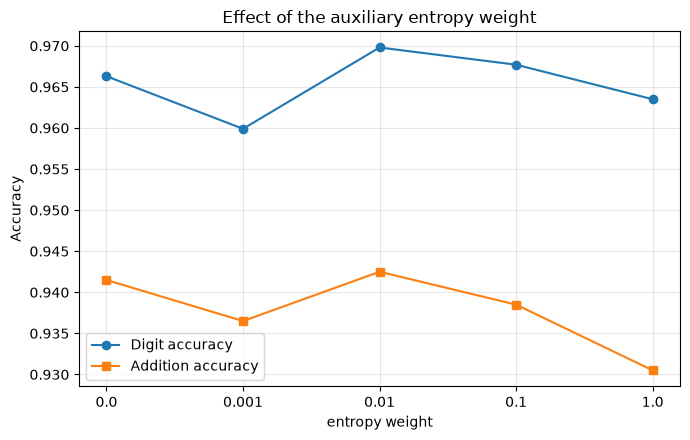

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))

labels = [str(w) for w in entropy_weights]
x = range(len(entropy_weights))
digit_accs = [results[w]["digit_acc"][-1] for w in entropy_weights]
add_accs = [results[w]["add_acc"][-1] for w in entropy_weights]

ax.plot(x, digit_accs, marker="o", label="Digit accuracy")
ax.plot(x, add_accs, marker="s", label="Addition accuracy")
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_xlabel("entropy weight")
ax.set_ylabel("Accuracy")
ax.set_title("Effect of the auxiliary entropy weight")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Small weights (0.001, 0.01) barely move either metric relative to the `entropy_weight=0` baseline (addition constraint alone): the differences are within run-to-run noise. `entropy_weight=0.1` is roughly on par with the baseline too. `entropy_weight=1.0` is measurably worse on both metrics.

Unlike the original Semi-Supervised MNIST notebook -- where the exactly-one constraint was the *only* source of extra signal beyond 50 labels, and clearly helped -- here the addition constraint alone already provides a comparatively strong, diverse training signal across 10,000 pairs. The entropy term has much less room to add value, and at high enough weight it actively competes with the addition constraint rather than complementing it.

The per-epoch curves make the failure mode at `entropy_weight=1.0` concrete:

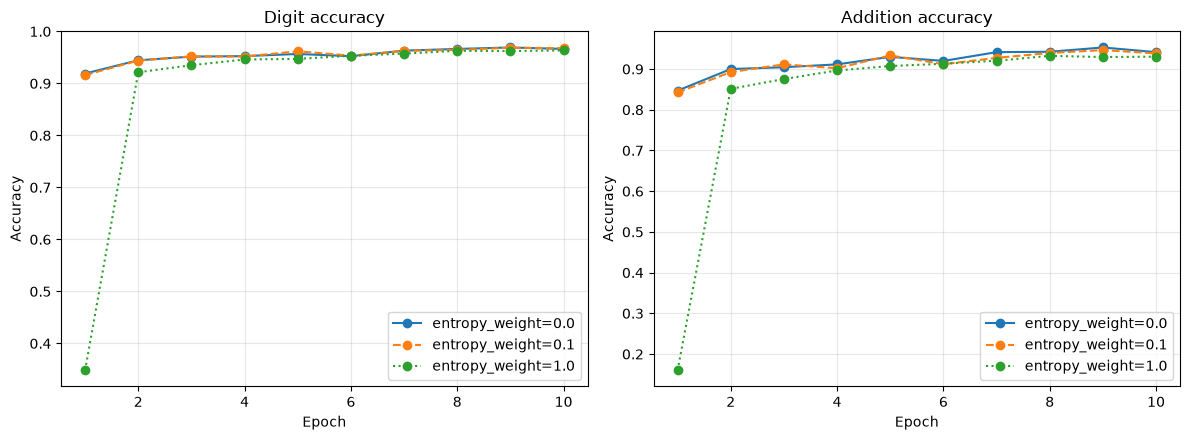

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for w, style in [(0.0, "-"), (0.1, "--"), (1.0, ":")]:
    epochs = range(1, len(results[w]["digit_acc"]) + 1)
    axes[0].plot(epochs, results[w]["digit_acc"], style, marker="o",
                 label=f"entropy_weight={w}")
    axes[1].plot(epochs, results[w]["add_acc"], style, marker="o",
                 label=f"entropy_weight={w}")

axes[0].set_title("Digit accuracy")
axes[1].set_title("Addition accuracy")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

At `entropy_weight=1.0`, the model collapses in epoch 1: the entropy constraint pushes the randomly initialized classifier toward confident, one-hot predictions before the addition constraint has taught it anything about *which* digit is which. Once addition supervision accumulates over subsequent epochs it recovers, but it never quite catches up to the lower-weight runs by epoch 10. At weight 0.1 the same dynamic is present but too weak to visibly hurt; the addition constraint dominates from the start.

This is the practical case for `CombinedLoss.weights` as a first-class, swept hyperparameter rather than a hardcoded `1.0`: the "obviously reasonable" logical constraint (every image should have exactly one predicted digit -- true by construction once training converges) is actively harmful early in training at the wrong weight, and that only shows up once you sweep it.

## Next steps

See the [Combining Multiple Losses](https://pysignet.github.io/concepts/#combining-multiple-losses) section of the docs for when to use `CombinedLoss` (independent constraints, loss-level combination) versus `sp.And` plus a single `compile_logic`/`logic_to_loss` call (shared predicates/variables, satisfaction-level combination).